In [3]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import h5py

def get_dataset_name(file_name_with_dir):
    filename_without_dir = file_name_with_dir.split('/')[-1]
    temp = filename_without_dir.split('_')[:-1]
    dataset_name = "_".join(temp)
    return dataset_name

## Data exploration
In this section we are experimenting with the data and how it is stored. We have not worked with MEG data before and the filing and data types are still unclear

In [5]:
DATASET_PATH = "/Users/stijnroos/VisualStudio/DL_data/"

RAW_FOLDERS = {
    "intra_train": os.path.join(DATASET_PATH, "Intra", "train"),
    "intra_test": os.path.join(DATASET_PATH, "Intra", "test"),
    "cross_train": os.path.join(DATASET_PATH, "Cross", "train"),
    "cross_test1": os.path.join(DATASET_PATH, "Cross", "test1"),
    "cross_test2": os.path.join(DATASET_PATH, "Cross", "test2"),
    "cross_test3": os.path.join(DATASET_PATH, "Cross", "test3"),
}

def parse_filename(path):
    name = os.path.basename(path).replace(".h5", "")
    parts = name.split("_")
    subject = parts[-2]
    chunk = int(parts[-1])
    task = "_".join(parts[:-2])
    return task, subject, chunk

rows = []

for split_name, folder in RAW_FOLDERS.items():
    files = sorted(glob.glob(os.path.join(folder, "*.h5")))
    for file in files:
        task, subject, chunk = parse_filename(file)
        rows.append({
            "split": split_name,
            "file": os.path.basename(file),
            "task": task,
            "subject": subject,
            "chunk": chunk,
            "path": file
        })

df_files = pd.DataFrame(rows)
df_files.head(10)

,split,file,task,subject,chunk,path
0,intra_train,rest_105923_1.h5,rest,105923,1,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
1,intra_train,rest_105923_2.h5,rest,105923,2,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
2,intra_train,rest_105923_3.h5,rest,105923,3,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
3,intra_train,rest_105923_4.h5,rest,105923,4,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
4,intra_train,rest_105923_5.h5,rest,105923,5,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
5,intra_train,rest_105923_6.h5,rest,105923,6,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
6,intra_train,rest_105923_7.h5,rest,105923,7,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
7,intra_train,rest_105923_8.h5,rest,105923,8,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
8,intra_train,task_motor_105923_1.h5,task_motor,105923,1,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
9,intra_train,task_motor_105923_2.h5,task_motor,105923,2,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...


In [6]:
print("Total files:", len(df_files))
display(df_files.groupby(["split", "task"]).size().unstack(fill_value=0))
display(df_files.groupby(["split", "subject"]).size().unstack(fill_value=0))
display(df_files.groupby(["split", "task", "subject"]).size())

Total files: 152


task,rest,task_motor,task_story_math,task_working_memory
split,,,,
cross_test1,4,4,4,4
cross_test2,4,4,4,4
cross_test3,4,4,4,4
cross_train,16,16,16,16
intra_test,2,2,2,2
intra_train,8,8,8,8


subject,105923,113922,162935,164636,707749,725751,735148
split,,,,,,,
cross_test1,0,0,16,0,0,0,0
cross_test2,0,0,0,0,16,0,0
cross_test3,0,0,0,0,0,8,8
cross_train,0,32,0,32,0,0,0
intra_test,8,0,0,0,0,0,0
intra_train,32,0,0,0,0,0,0


split        task                 subject
cross_test1  rest                 162935     4
             task_motor           162935     4
             task_story_math      162935     4
             task_working_memory  162935     4
cross_test2  rest                 707749     4
             task_motor           707749     4
             task_story_math      707749     4
             task_working_memory  707749     4
cross_test3  rest                 725751     2
                                  735148     2
             task_motor           725751     2
                                  735148     2
             task_story_math      725751     2
                                  735148     2
             task_working_memory  725751     2
                                  735148     2
cross_train  rest                 113922     8
                                  164636     8
             task_motor           113922     8
                                  164636     8
             task_

In [7]:
def read_h5_file(filepath):
    with h5py.File(filepath, "r") as f:
        keys = list(f.keys())
        if len(keys) != 1:
            raise ValueError(f"Expected one dataset, found {keys}")
        dataset_name = keys[0]
        X = f[dataset_name][()]
    return X, dataset_name

In [8]:
sample_file = df_files.iloc[0]["path"]

X, dataset_name = read_h5_file(sample_file)

print("File:", os.path.basename(sample_file))
print("Dataset name:", dataset_name)

print("Shape:", X.shape)
print("Dtype:", X.dtype)

print("\nStatistics:")
print("Min:", X.min())
print("Max:", X.max())
print("Mean:", X.mean())
print("Std:", X.std())

print("\nMemory usage (MB):")
print(X.nbytes / 1024**2)

File: rest_105923_1.h5
Dataset name: rest_105923
Shape: (248, 35624)
Dtype: float64

Statistics:
Min: -2.788253829211218e-11
Max: 1.3240070498299339e-11
Mean: 4.094354904508632e-14
Std: 4.909138310890537e-12

Memory usage (MB):
67.40380859375


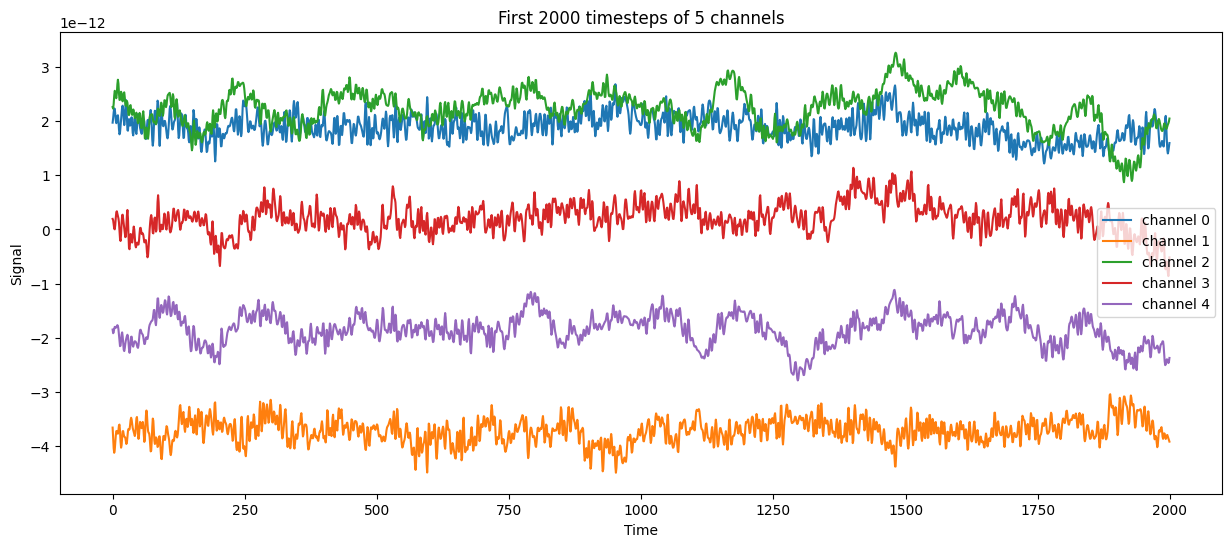

In [9]:
plt.figure(figsize=(15, 6))

for i in range(5):
    plt.plot(X[i, :2000], label=f"channel {i}")

plt.title("First 2000 timesteps of 5 channels")
plt.xlabel("Time")
plt.ylabel("Signal")
plt.legend()
plt.show()

In [10]:
summary_rows = []

for _, row in df_files.iterrows():
    X, key = read_h5_file(row["path"])
    summary_rows.append({
        "split": row["split"],
        "task": row["task"],
        "subject": row["subject"],
        "file": row["file"],
        "key": key,
        "shape": X.shape,
        "dtype": str(X.dtype),
        "min": X.min(),
        "max": X.max(),
        "mean": X.mean(),
        "std": X.std(),
        "memory_mb": X.nbytes / 1024**2
    })

df_summary = pd.DataFrame(summary_rows)

print("Unique shapes:", df_summary["shape"].unique())
print("Unique dtypes:", df_summary["dtype"].unique())
print("Total memory if fully loaded:", df_summary["memory_mb"].sum(), "MB")

display(df_summary.groupby(["split", "task"])[["min", "max", "mean", "std"]].mean())

Unique shapes: [(248, 35624)]
Unique dtypes: ['float64']
Total memory if fully loaded: 10245.37890625 MB


min           max          mean  \
split       task                                                            
cross_test1 rest                -2.417695e-11  3.281256e-11  1.403908e-12   
            task_motor          -1.464510e-10  7.328023e-12 -7.675851e-13   
            task_story_math     -3.735773e-11  8.140740e-12 -5.553890e-14   
            task_working_memory -2.269747e-10  2.222397e-11  1.871512e-13   
cross_test2 rest                -2.875010e-11  4.002255e-11  9.717947e-13   
            task_motor          -3.794924e-10  2.322366e-11 -1.191946e-12   
            task_story_math     -2.524722e-10  5.578384e-11 -2.131746e-12   
            task_working_memory -1.533678e-10  3.495876e-11 -1.475140e-12   
cross_test3 rest                -3.125810e-11  4.289565e-11  1.283255e-12   
            task_motor          -1.299066e-10  9.812833e-12  5.323511e-13   
            task_story_math     -2.769507e-10  2.542496e-11 -1.071959e-12   
            task_working_memory -2.144747e-10  1.117858e-11 -1.130372e-12   
cross_train rest                -4.085917e-11  3.935921e-11  7.736768e-13   
            task_motor          -1.719962e-10  1.275309e-11 -1.008501e-13   
            task_story_math     -4.938406e-11  5.351631e-12  7.213017e-14   
            task_working_memory -2.197490e-10  8.873976e-12 -4.459452e-13   
intra_test  rest                -4.838124e-11  3.469089e-11  3.040459e-12   
            task_motor          -3.375209e-10  1.352729e-11 -1.250118e-12   
            task_story_math     -1.157972e-10  9.403583e-12  6.512599e-13   
            task_working_memory -1.721721e-10  1.897677e-11  1.838611e-12   
intra_train rest                -4.434478e-11  2.221766e-11  1.442381e-12   
            task_motor          -1.959208e-10  9.899276e-12 -3.933353e-13   
            task_story_math     -9.156647e-11  9.634018e-12  1.064854e-12   
            task_working_memory -1.371398e-10  1.494194e-11  1.134688e-12   

                                          std  
split       task                               
cross_test1 rest                 4.249768e-12  
            task_motor           8.923254e-12  
            task_story_math      2.304083e-12  
            task_working_memory  1.387564e-11  
cross_test2 rest                 1.008465e-11  
            task_motor           2.413086e-11  
            task_story_math      1.618756e-11  
            task_working_memory  1.138280e-11  
cross_test3 rest                 9.217902e-12  
            task_motor           8.063570e-12  
            task_story_math      1.731163e-11  
            task_working_memory  1.308854e-11  
cross_train rest                 6.364122e-12  
            task_motor           1.043408e-11  
            task_story_math      3.122570e-12  
            task_working_memory  1.343616e-11  
intra_test  rest                 1.341991e-11  
            task_motor           2.068997e-11  
            task_story_math      7.561008e-12  
            task_working_memory  1.134360e-11  
intra_train rest                 8.654158e-12  
            task_motor           1.171845e-11  
            task_story_math      5.972657e-12  
            task_working_memory  8.728497e-12

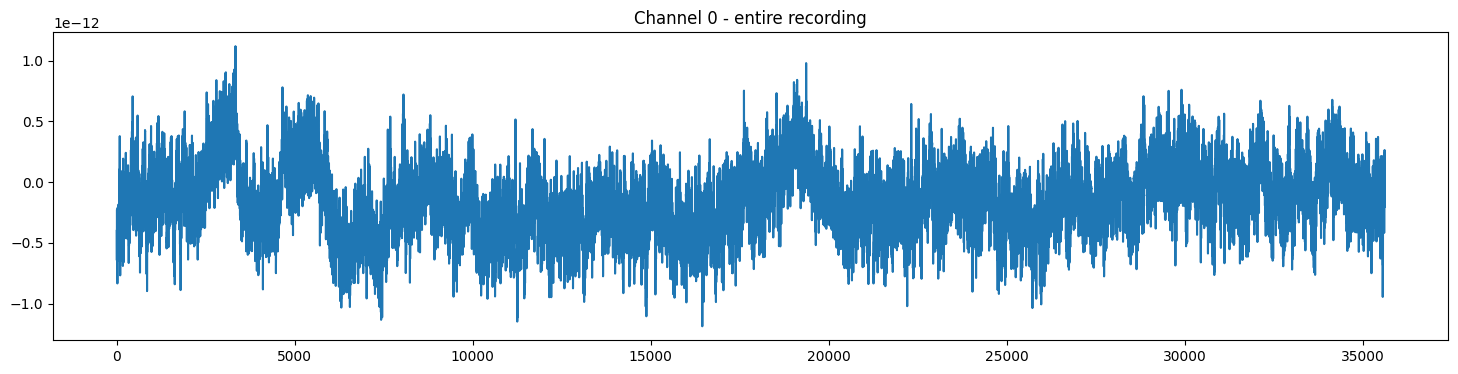

In [11]:
channel = 0

plt.figure(figsize=(18,4))
plt.plot(X[channel])
plt.title(f"Channel {channel} - entire recording")
plt.show()

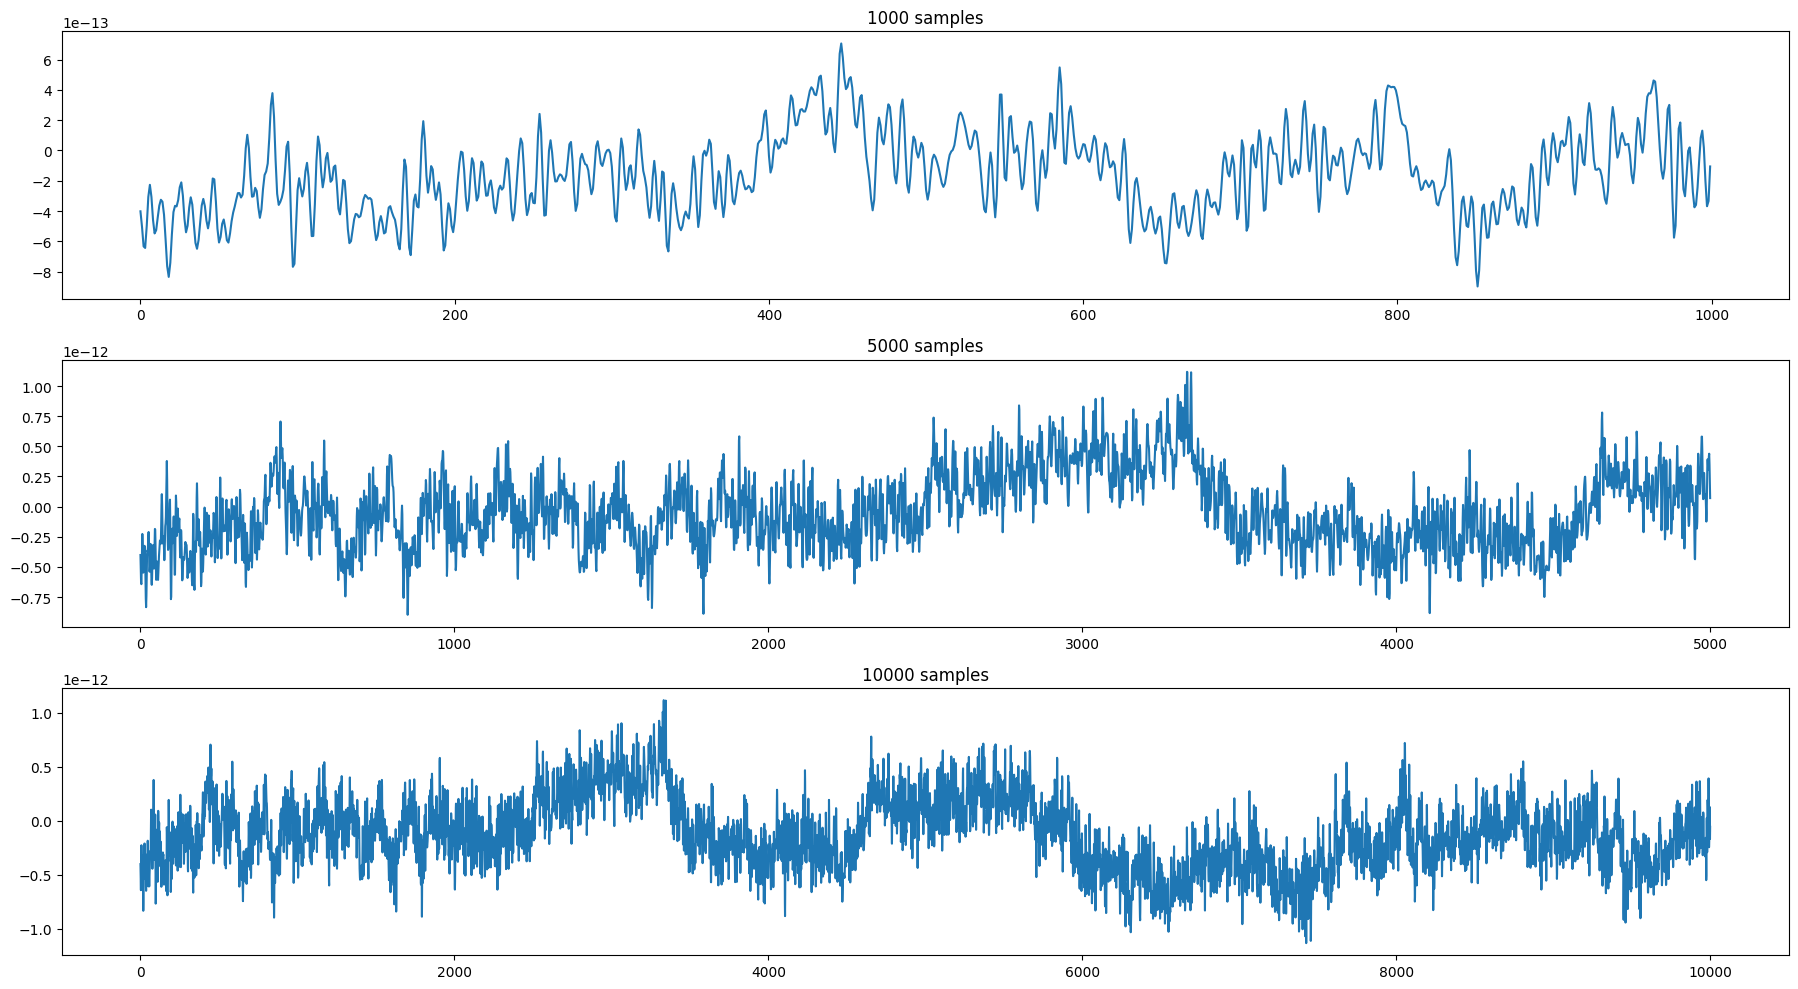

In [12]:
channel = 0

fig, axes = plt.subplots(3, 1, figsize=(18,10))

axes[0].plot(X[channel, :1000])
axes[0].set_title("1000 samples")

axes[1].plot(X[channel, :5000])
axes[1].set_title("5000 samples")

axes[2].plot(X[channel, :10000])
axes[2].set_title("10000 samples")

plt.tight_layout()
plt.show()

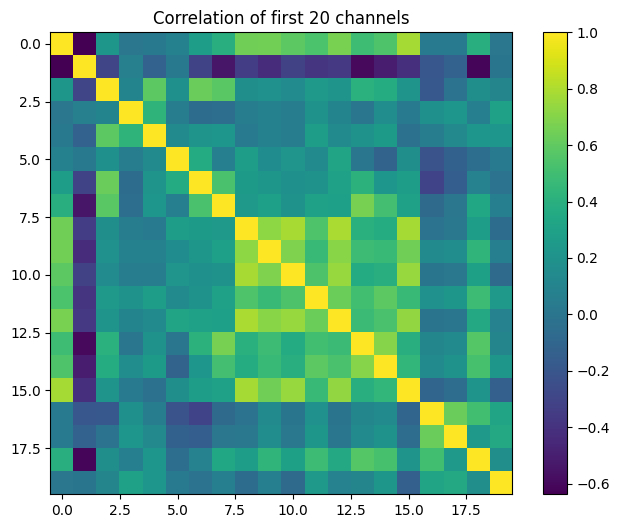

In [13]:
corr = np.corrcoef(X[:20])

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation of first 20 channels")
plt.show()

In [14]:
sample_rate = 2034
duration = X.shape[1] / sample_rate

print("Duration (seconds):", duration)

for factor in [2, 4, 8]:
    print(
        f"factor={factor:2d} -> "
        f"{X.shape[1]//factor} timesteps"
    )

Duration (seconds): 17.514257620452312
factor= 2 -> 17812 timesteps
factor= 4 -> 8906 timesteps
factor= 8 -> 4453 timesteps


Original shape: (248, 35624)
Downsampled shape: (248, 3563)


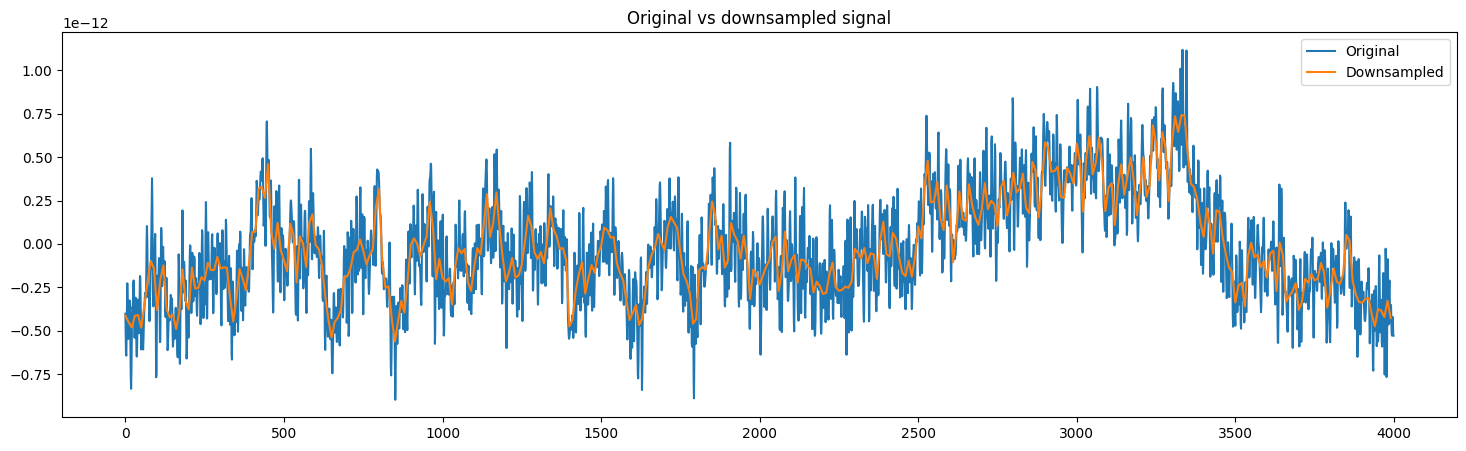

Raw stats:
-1.1668739564185331e-12 1.3227933298550109e-11 -2.1524897142466415e-10 1.1000712493713927e-11

Downsampled stats:
-1.1535503744497695e-12 1.3075229171043445e-11 -2.1203253606867918e-10 1.0220929630441216e-11


In [15]:
from scipy.signal import decimate

# try factor 4 downsampling and plot the difference
factor = 10
channel = 0

X_down = decimate(X, q=factor, axis=1, zero_phase=True)

print("Original shape:", X.shape)
print("Downsampled shape:", X_down.shape)

plt.figure(figsize=(18, 5))
plt.plot(X[channel, :4000], label="Original")
plt.plot(
    np.arange(0, 4000, factor),
    X_down[channel, :4000 // factor],
    label="Downsampled",
)
plt.title("Original vs downsampled signal")
plt.legend()
plt.show()

print("Raw stats:")
print(X.mean(), X.std(), X.min(), X.max())

print("\nDownsampled stats:")
print(X_down.mean(), X_down.std(), X_down.min(), X_down.max())